In [1]:
import numpy as np
import time
from gwspace.response import trans_AET_fd
from gwspace.Waveform import waveforms
from gwspace.response import get_y_slr_td, trans_y_slr_fd, get_XYZ_td, tdi_XYZ2AET
from gwspace.Orbit import detectors
import lalsimulation
from gwspace.constants import MSUN_SI, MPC_SI,MONTH
import scipy
from gwspace.utils import sYlm
from gwspace.constants import MSUN_SI, MTSUN_SI, MPC_SI, YRSID_SI, PI, PI_2, C_SI
import math
import matplotlib.pyplot as plt
from gwspace.Noise import TianQinNoise
import bilby
import dynesty
import dynesty.plotting as dyplot # 用于绘图
from dynesty.utils import resample_equal 
import pandas as pd
from scipy.interpolate import interp1d
DAY=3600*24

/home/zhantch/anaconda3/envs/sage/lib/python3.9/site-packages/lalsimulation/lalsimulation.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
def p0_plus_cross(Lambda, Beta):
    """See Marsat et al. (Eq. 14)"""
    sib, csb = np.sin(Beta), np.cos(Beta)
    sil, csl = np.sin(Lambda), np.cos(Lambda)
    sil2, csl2 = np.sin(2*Lambda), np.cos(2*Lambda)

    p0_plus = np.array([-sib**2*csl**2+sil**2, (sib**2+1)*(-sil*csl), sib*csb*csl,
                        (sib**2+1)*(-sil*csl), -sib**2*sil**2+csl**2, sib*csb*sil,
                        sib*csb*csl, sib*csb*sil, -csb**2]).reshape(3, 3)
    p0_cross = np.array([-sib*sil2, sib*csl2, csb*sil,
                         sib*csl2, sib*sil2, -csb*csl,
                         csb*sil, -csb*csl, 0]).reshape(3, 3)
    return p0_plus, p0_cross

def get_amp_phase(h):
    amp=np.abs(h)
    phase = np.unwrap(np.angle(h))
    return amp,phase

def p_lm(Lambda,Beta,iota,psi, l, m):
        """See Marsat et al. (Eq. 16) https://journals.aps.org/prd/abstract/10.1103/PhysRevD.103.083011"""
        p0_plus, p0_cross = p0_plus_cross(Lambda, Beta)
        y_lm = sYlm(-2, l, m, iota, 0)
        y_l_m_conj = sYlm(-2, l, -m, iota, 0).conjugate()
        return (1/2 * y_lm * np.exp(-2j*psi) * (p0_plus + 1j*p0_cross) +
                1/2 * (-1)**l * y_l_m_conj * np.exp(2j*psi) * (p0_plus - 1j*p0_cross))

def vec_k(Lambda,Beta):
    return np.array([-np.cos(Beta)*np.cos(Lambda),
                        -np.cos(Beta)*np.sin(Lambda),
                        -np.sin(Beta)])

def XHM_TDI(freq,l,m,m1_SI,m2_SI,s1x,s1y,s1z,s2x,s2y,s2z,distance,f_ref,tc,Lambda,Beta,iota,psi,phic):
    amp = lalsimulation.SimIMRPhenomXHMAmplitude(freq, l, m, m1_SI, m2_SI, s1x,s1y,s1z,s2x,s2y,s2z,distance, 0,f_ref, dict())
    phase = lalsimulation.SimIMRPhenomXHMPhase(freq, l, m, m1_SI, m2_SI, s1x,s1y,s1z,s2x,s2y,s2z,distance, 0,f_ref, dict())
    amp = amp.data
    phase = phase.data
    phase=phase-phase[-1]-(m/2)*phic
    hlm = amp * np.exp(-1j * phase)
    tfspline = scipy.interpolate.InterpolatedUnivariateSpline(freq, (phase - phase[0])/(2*np.pi))
    tfspline_d = tfspline.derivative()
    tf = tfspline_d(freq)+tc
    k=vec_k(Lambda,Beta)
    plm=p_lm(Lambda,Beta,iota,psi, l, m)
    gw_tdi = np.zeros(shape=(3, len(freq)), dtype=np.complex128)
    det = detectors['TQ'](tf)
    gw_tdi_lm = trans_AET_fd(k, plm, det, freq, 1)[0]
    gw_tdi = gw_tdi_lm * hlm
    A,E,T=gw_tdi*np.exp(-1j*2*PI*freq*tc)
    return A,E

def PhenomXHM_tdi(frequency_array, modes, **params):
    chirp_mass = params['chirp_mass']
    eta = params['eta']
    chi1x = params['chi1x']
    chi1y = params['chi1y']
    chi1z = params['chi1z']
    chi2x = params['chi2x']
    chi2y = params['chi2y']
    chi2z = params['chi2z']
    DL = params['DL']
    f_ref = params['f_ref']
    psi = params['psi']
    iota = params['iota']
    lon = params['lon']
    lat = params['lat']
    tc = params['tc']
    phic = params['phic']

    mass_1=chirp_mass * eta**(-3/5)*(1+np.sqrt(1-4*eta))/2
    mass_2=chirp_mass * eta**(-3/5)*(1-np.sqrt(1-4*eta))/2
    minf = 1e-5
    maxf = 0.1
    inds = (frequency_array >= minf) & (frequency_array <= maxf)
    Lambda,Beta=lon,lat
    m1_si = mass_1 * MSUN_SI
    m2_si = mass_2 * MSUN_SI
    dl_si = DL * MPC_SI
    signalA=np.zeros_like(frequency_array,dtype=np.complex128)
    signalE=np.zeros_like(frequency_array,dtype=np.complex128)
    signal1=np.zeros_like(frequency_array,dtype=np.complex128)
    signal2=np.zeros_like(frequency_array,dtype=np.complex128)
    for ii, (l, m) in enumerate(modes):
        signal1[inds],signal2[inds]=XHM_TDI(
            frequency_array[inds],l,m,m1_si,m2_si,
            chi1x,chi1y,chi1z,chi2x,chi2y,chi2z, # 传递提取出的值
            dl_si,f_ref,tc,Lambda,Beta,iota,psi,phic # 传递提取出的值
        )
        signalA+=signal1
        signalE+=signal2
    return {'A': signalA, 'E': signalE,'inds':inds}

def XHM(freq,l,m,m1_SI,m2_SI,s1x,s1y,s1z,s2x,s2y,s2z,distance,f_ref,tc,Lambda,Beta,iota,psi,phic):
    amp = lalsimulation.SimIMRPhenomXHMAmplitude(freq, l, m, m1_SI, m2_SI, s1x,s1y,s1z,s2x,s2y,s2z,distance, 0,f_ref, dict())
    phase = lalsimulation.SimIMRPhenomXHMPhase(freq, l, m, m1_SI, m2_SI, s1x,s1y,s1z,s2x,s2y,s2z,distance, 0,f_ref, dict())
    amp = amp.data
    phase = phase.data
    phase=phase-(m/2)*phic
    hlm = amp * np.exp(-1j * phase+1j*2*PI*freq*tc)
    return hlm

def PhenomXHM(frequency_array, modes, **params):
    chirp_mass = params['chirp_mass']
    eta = params['eta']
    chi1x = params['chi1x']
    chi1y = params['chi1y']
    chi1z = params['chi1z']
    chi2x = params['chi2x']
    chi2y = params['chi2y']
    chi2z = params['chi2z']
    DL = params['DL']
    f_ref = params['f_ref']
    psi = params['psi']
    iota = params['iota']
    lon = params['lon']
    lat = params['lat']
    tc = params['tc']
    phic = params['phic']

    mass_1=chirp_mass * eta**(-3/5)*(1+np.sqrt(1-4*eta))/2
    mass_2=chirp_mass * eta**(-3/5)*(1-np.sqrt(1-4*eta))/2
    minf = 1e-5
    maxf = 0.1
    inds = (frequency_array >= minf) & (frequency_array <= maxf)
    Lambda,Beta=lon,lat
    m1_si = mass_1 * MSUN_SI
    m2_si = mass_2 * MSUN_SI
    dl_si = DL * MPC_SI
    hi=np.zeros_like(frequency_array,dtype=np.complex128)
    h_total=np.zeros_like(frequency_array,dtype=np.complex128)
    for ii, (l, m) in enumerate(modes):
        hi[inds]=XHM(
            frequency_array[inds],l,m,m1_si,m2_si,
            chi1x,chi1y,chi1z,chi2x,chi2y,chi2z, # 传递提取出的值
            dl_si,f_ref,tc,Lambda,Beta,iota,psi,phic # 传递提取出的值
        )
        h_total+=hi
    return h_total

def ifft_corrected(f, arr, T_obs, dt):
    df = 1.0 / T_obs
    kmin = round(f[0] / df)
    kmin = int(kmin)

    n = round(1.0 / (dt * df))
    n_freq = int(n / 2 + 1)
    ret = np.zeros(n_freq, dtype=arr.dtype)

    arr_len = len(arr)
    if kmin + arr_len > n_freq:
        arr_len = n_freq - kmin # 截断
        if arr_len < 0: arr_len = 0
            
    if arr_len > 0:
        ret[kmin : kmin + arr_len] = arr[:arr_len]
    
    X = np.fft.irfft(ret)
    t = np.arange(len(X)) * dt
    return t, X

In [3]:
T_obs_nominal =  12*MONTH  
dt = 1
df_nominal = 1.0 / T_obs_nominal
n = round(1.0 / (dt * df_nominal))
T_obs = n * dt     
df = 1.0 / T_obs   
tc = T_obs / 2.0   
print(f" T_obs (n*dt): {T_obs:.4f} s")
print(f" df (1/T_obs): {df:.5e} Hz")
f_min = 1e-5
f_max = 1.0 / (2.0 * dt) 

params = {
    "chirp_mass": 433113, "eta": 0.1, "chi1x": 0, "chi1y": 0, 
    "chi1z": 0.6, "chi2x": 0, "chi2y": 0, "chi2z": 0.4, "DL": 6000, 
    "f_ref": 1e-6, "T_obs": T_obs, "psi": 0.7, "iota": 1.1, "lon": 1.2, 
    "lat": 0.7, "tc": tc, "phic": 1.2
}
modes =[[2, 2], [2, 1], [3, 3], [3, 2], [4, 4]]
kmin = int(np.ceil(f_min / df))
f_start_aligned = kmin * df
ff_orig = np.arange(f_start_aligned, f_max, df)
if ff_orig[-1] >= f_max:
    ff_orig = ff_orig[:-1]
waveforms_XHM=PhenomXHM_tdi(ff_orig, modes, **params)
A_orig = waveforms_XHM['A']
E_orig = waveforms_XHM['E']
time_full,A_td_full = ifft_corrected(ff_orig, A_orig, T_obs, dt)
time_full,E_td_full = ifft_corrected(ff_orig, E_orig, T_obs, dt)

 T_obs (n*dt): 31104000.0000 s
 df (1/T_obs): 3.21502e-08 Hz


(15549000.0, 15554000.0)

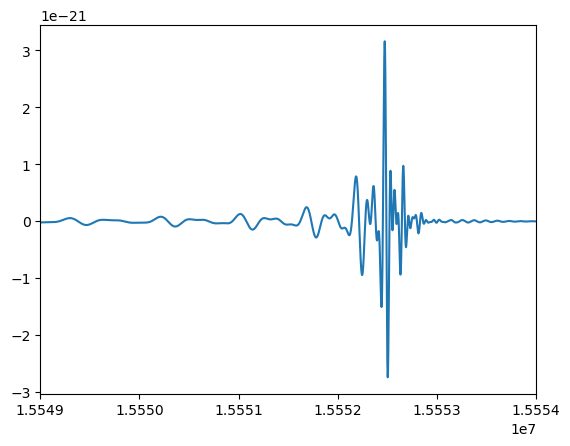

In [4]:
plt.plot(time_full,A_td_full)
plt.xlim(tc-3000,tc+2000)